# 09_聚类算法-均值漂移

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家聊聊均值漂移\~

**均值漂移（Mean Shift）** 是一种无监督的聚类算法，用于发现数据集中的“高密度区域”。它不需要指定聚类的个数，而是通过一种叫“核密度估计”的方法找到数据分布的高峰（即密度最大的位置）。

算法的核心思想是：**通过不断移动数据点到其密度最大的地方（均值），最终形成聚类中心。**

这里，咱们举一个非常简单的例子：

在一个静止的水塘里，有许多小船（数据点）分散在水面上。

1. 每只小船都想找到“人最多”的地方停下。
2. 于是它们会观察周围一片水域（一个圆圈，称为**窗口**），计算附近有多少船，找到一个“平均位置”（局部密度中心）。
3. 然后，小船移动到那个平均位置。
4. 不断重复这一过程，直到所有小船都聚到某个“湖心”（密度峰值），最终形成一个个聚类中心。

### 均值漂移的算法步骤

1. **初始化窗口（半径 bandwidth）**：选择一个半径 $h$的圆，称为核窗口，包含附近的数据点。
2. **计算均值（移动的方向）**：对于每个点，找到其窗口内所有点的均值（数据点的平均值）。
3. **移动数据点**：将点移动到计算出的均值位置。
4. **重复迭代**：重复步骤 2 和 3，直到数据点的位置不再变化或变化很小。
5. **合并相近的中心点**：如果多个点最终聚到了同一个地方，它们就属于同一个聚类。

### 举一个通俗易懂的案例

**场景：分组糖果机里的糖果**

假设你有一个糖果机，里面有不同种类的糖果（橘子味、草莓味、蓝莓味）。糖果随机撒在一张桌子上，分布如下。糖果位置（数据点）：


$$
(1, 2), (2, 2), (3, 2), (8, 8), (9, 8), (9, 9)
$$


我们想要用均值漂移算法将这些糖果分成不同组。

#### 步骤 1：选择一个窗口半径 $h = 3$

半径 $h$决定了每个糖果看多远范围的邻居，比如我们选 $h = 3$。糖果看自己周围 3 个单位内的糖果。

#### 步骤 2：初始化每个糖果的位置

一开始每个糖果自己单独计算均值，不断调整位置。

1. **糖果 (1, 2)：**

   - 邻居：$(1, 2), (2, 2), (3, 2)$
   - 均值（平均值）：$x = \frac{1+2+3}{3} = 2, \quad y = \frac{2+2+2}{3} = 2$
   - 移动到 (2, 2)。
2. **糖果 (2, 2)：**

   - 邻居：$(1, 2), (2, 2), (3, 2)$
   - 均值相同，移动到 (2, 2)。
3. **糖果 (3, 2)：**

   - 邻居：$(1, 2), (2, 2), (3, 2)$
   - 均值相同，移动到 (2, 2)。
4. **糖果 (8, 8)：**

   - 邻居：$(8, 8), (9, 8), (9, 9)$
   - 均值：$x = \frac{8+9+9}{3} = 8.67, \quad y = \frac{8+8+9}{3} = 8.33$
   - 移动到 (8.67, 8.33)。
5. **糖果 (9, 8)：**

   - 邻居：$(8, 8), (9, 8), (9, 9)$
   - 均值相同，移动到 (8.67, 8.33)。
6. **糖果 (9, 9)：**

   - 邻居：$(8, 8), (9, 8), (9, 9)$
   - 均值相同，移动到 (8.67, 8.33)。

#### 步骤 3：合并点

经过多次迭代，糖果分布稳定：

- 第一组糖果：$(2, 2)$
- 第二组糖果：$(8.67, 8.33)$

最终结果是两个聚类中心：


$$
(2, 2), (8.67, 8.33)
$$


### 核心总结

- **优点**：不需要提前知道聚类个数；适合数据密度不均匀的情况。
- **缺点**：计算复杂度较高，对窗口半径 $h$很敏感。

## 公式解析

均值漂移的核心思想是通过核密度估计找到数据分布的高密度区域，并迭代更新数据点位置到密度的高峰点。以下是详细的数学公式推导过程。

### 1. 核密度估计

核密度估计用于估计某个点附近的概率密度函数。

给定一个数据集 $\{x_1, x_2, \dots, x_n\} \subseteq \mathbb{R}^d$，核密度估计公式为：


$$
f(x) = \frac{1}{n h^d} \sum_{i=1}^n K\left(\frac{\|x - x_i\|}{h}\right)
$$


- $f(x)$：估计点 $x$的密度。
- $h$：核窗口宽度（bandwidth）。
- $K(\cdot)$：核函数（通常选择高斯核 $K(u) = e^{-\|u\|^2 / 2}$）。
- $\|x - x_i\|$：点 $x$到 $x_i$的欧几里得距离。

#### 核密度解释：

- 每个点 $x_i$对周围密度 $f(x)$有贡献，贡献大小由核函数 $K$和窗口宽度 $h$决定。
- $f(x)$表示点 $x$周围所有点的加权密度估计。

### 2. 梯度（密度上升方向）

均值漂移算法基于密度梯度上升的思想。密度梯度 $\nabla f(x)$的方向可以表示为：


$$
\nabla f(x) = \frac{\partial f(x)}{\partial x}
$$


代入核密度估计公式，$f(x)$的梯度为：

- $\nabla f(x) = \frac{1}{n h^{d+2}} \sum_{i=1}^n K'\left(\frac{\|x - x_i\|}{h}\right) \cdot (x_i - x)$
- $K'(u)$是核函数 $K(u)$的导数。
- 梯度方向为 $x_i - x$，即数据点 $x$朝高密度区域的点移动。

在高斯核下，梯度公式可以进一步简化为：


$$
\nabla f(x) \propto \sum_{i=1}^n (x_i - x) \cdot e^{-\frac{\|x - x_i\|^2}{2h^2}}
$$


### 3. 均值漂移向量

均值漂移向量定义为：


$$
m(x) = \frac{\sum_{i=1}^n x_i \cdot K\left(\frac{\|x - x_i\|}{h}\right)}{\sum_{i=1}^n K\left(\frac{\|x - x_i\|}{h}\right)} - x
$$


- **分子**：核权重 $K$加权后的数据点平均值。
- **分母**：核权重的归一化因子，确保权重和为 1。

这个向量 $m(x)$指向密度最大的方向，也就是数据点应该移动的方向。

**推导解释：**

**加权均值计算**：首先计算当前点 $x$周围点的加权均值：


$$
\mu(x) = \frac{\sum_{i=1}^n x_i \cdot K\left(\frac{\|x - x_i\|}{h}\right)}{\sum_{i=1}^n K\left(\frac{\|x - x_i\|}{h}\right)}
$$


其中，$K\left(\frac{\|x - x_i\|}{h}\right)$是点 $x_i$对点 $x$的权重。

**均值漂移**：当前点 $x$到均值 $\mu(x)$的偏移为：


$$
m(x) = \mu(x) - x
$$


### 4. 均值漂移的更新公式

在每次迭代中，将当前点 $x$更新为均值位置：


$$
x \leftarrow x + m(x) = \mu(x)
$$


迭代过程重复计算加权均值，逐步将点 $x$移动到密度最大的位置（即核密度估计的峰值）。

### 5. 算法的收敛性

均值漂移算法的收敛性基于以下两点：

1. 每次迭代都沿着密度梯度上升方向移动。
2. 密度函数 $f(x)$在移动过程中不断增加，最终达到局部最大值。

最终，所有点都会汇聚到密度函数的局部峰值，形成聚类中心。

### 总结公式

**核密度估计：**


$$
f(x) = \frac{1}{n h^d} \sum_{i=1}^n K\left(\frac{\|x - x_i\|}{h}\right)
$$


**梯度（密度方向）：**


$$
\nabla f(x) = \frac{1}{n h^{d+2}} \sum_{i=1}^n K'\left(\frac{\|x - x_i\|}{h}\right) \cdot (x_i - x)
$$


**均值漂移向量：**


$$
m(x) = \frac{\sum_{i=1}^n x_i \cdot K\left(\frac{\|x - x_i\|}{h}\right)}{\sum_{i=1}^n K\left(\frac{\|x - x_i\|}{h}\right)} - x
$$


**点的更新规则：**


$$
x \leftarrow x + m(x) = \mu(x)
$$


通过不断迭代上述更新公式，所有点最终聚集到局部密度峰值，形成聚类中心。

## 完整案例

一个使用聚类算法「均值漂移 (Mean Shift)」的完整案例，其中包括数据生成、聚类、和绘制炫酷、复杂的图形。我们使用 `scikit-learn` 中的 `MeanShift` 实现聚类，并用 `matplotlib` 和 `seaborn` 进行可视化。

使用均值漂移对二维数据聚类。

Number of clusters: 4


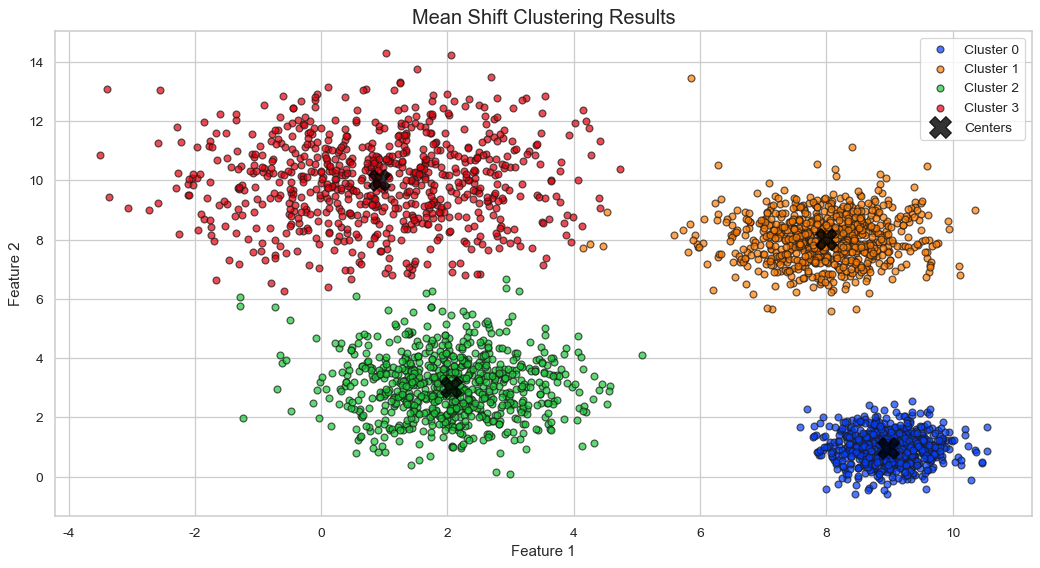

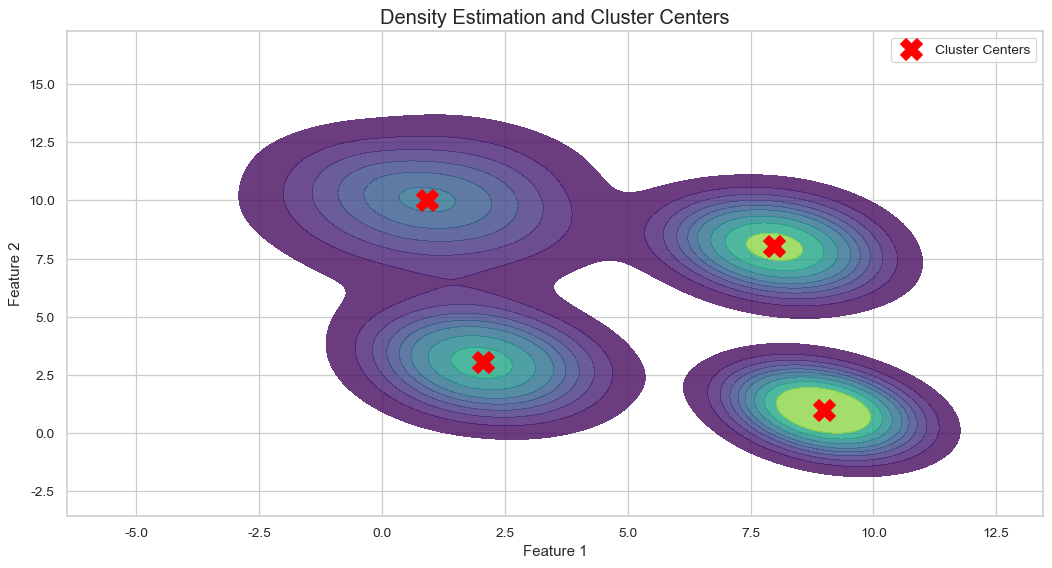

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs

# 设置绘图风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 1. 数据生成
centers = [[2, 3], [8, 8], [1, 10], [9, 1]]  # 指定聚类中心
cluster_std = [1.0, 0.8, 1.5, 0.5]  # 每个簇的标准差

# 生成样本数据
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=cluster_std, random_state=42)

# 2. 估计带宽并执行均值漂移聚类
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(X)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

n_clusters_ = len(np.unique(labels))

print(f"Number of clusters: {n_clusters_}")

# 3. 绘制结果图形

# 图 1: 数据分布和聚类结果
plt.figure(figsize=(14, 7))
unique_labels = np.unique(labels)
colors = sns.color_palette("bright", n_colors=n_clusters_)

for k, col in zip(unique_labels, colors):
    cluster_members = labels == k
    plt.scatter(X[cluster_members, 0], X[cluster_members, 1], c=[col], label=f"Cluster {k}", s=30, alpha=0.7, edgecolor='k')
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='black', s=300, alpha=0.8, label='Centers', marker='X')
plt.title("Mean Shift Clustering Results", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

# 图 2: 聚类后的密度估计
plt.figure(figsize=(14, 7))
sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, cmap="viridis", alpha=0.8)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', s=300, label='Cluster Centers', marker='X')
plt.title("Density Estimation and Cluster Centers", fontsize=16)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

# 显示图形
plt.show()

1. **数据生成**：通过 `make_blobs` 生成指定簇数的二维数据点，可以调整簇中心和标准差以获得多样化的数据分布。
2. **均值漂移聚类**：使用 `MeanShift` 聚类，并自动估计带宽（`estimate_bandwidth`）。

**图 1** 展示了数据的聚类结果，不同簇使用不同颜色表示，同时标注了聚类中心。

![原文参考图，当前结果见代码输出](attachments/img_004.png)

**图 2** 绘制数据点的密度分布图，使用核密度估计（KDE），并叠加聚类中心，体现数据密度的变化。

![原文参考图，当前结果见代码输出](attachments/img_005.png)

## 优缺点和适用场景

**优点**：

1. **不需要预定义聚类个数**：均值漂移不需要提前指定聚类的数量 \$\$k \$\$，而是通过数据密度分布自适应地找到聚类中心。
2. **适合不规则分布的数据**：由于是基于核密度估计，均值漂移可以很好地处理形状不规则、密度不均匀的数据。
3. **可以处理任意维度的数据**：均值漂移算法对数据的维度没有限制，可以用于低维和高维数据。
4. **稳健性**：算法对异常点（噪声）有一定的鲁棒性，因为它依赖局部密度而非全局的距离计算。
5. **自适应带宽调整**：可以扩展为具有可变带宽的均值漂移算法，从而更好地适应不同密度的区域。

**缺点**：

1. **计算复杂度高**：均值漂移每次迭代都需要计算点的加权均值，复杂度为 \$\$O(n^2) \$\$，对大规模数据集效率较低。
2. **对带宽（bandwidth）敏感**：带宽 \$\$h \$\$的选择对结果影响很大，带宽过大可能导致聚类中心合并，过小则可能导致过度分割。
3. **可能陷入局部最优**：算法可能会收敛到局部密度峰值，而非全局最优。
4. **结果依赖初始点**：数据点的初始位置和分布会影响收敛到的聚类中心位置。
5. **不适合高维稀疏数据**：在高维数据中，核密度估计的效果可能变差（“维数灾难”问题）。

### 适用场景

1. **数据分布密度未知的场景**：如果数据的聚类个数未知，且各个类的形状或密度差异较大，均值漂移是一种理想选择。
2. **处理非球形聚类**：均值漂移能很好地处理复杂形状的聚类，例如环形、弯曲或多峰分布的数据。
3. **模式识别**：均值漂移可用于图像分割、目标跟踪、视频处理等任务。
4. **异常检测**：可以通过高密度和低密度的划分，检测密度较低区域中的异常点。
5. **自动化数据分组**：适合用于没有清晰分组标准的场景，例如分组推荐系统中的用户行为数据。